# Does NIFTY recover after a significant one-day fall?

**Hypothesis (informal):** *After a significant one-day fall in NIFTY, the market tends to recover over the next few trading days.*

This notebook runs top-to-bottom. Every research rule is fixed in Section 3 **before** any outcome is computed, and all decisions (with reasons and alternatives) are logged in `docs/DECISIONS.md`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.data import load_clean

pd.set_option("display.width", 140)
RAW_PATH = ROOT / "data" / "raw" / "nifty50_niftyindices_raw.csv"

## 1. Data source

| Item | Value |
|---|---|
| Source | NIFTY Indices (NSE Indices Ltd) — official index provider — https://www.niftyindices.com/reports/historical-data |
| Series | NIFTY 50 price index, daily |
| Fields | Date, Open, High, Low, Close |
| Requested range | 01-Jan-2000 → latest available |
| How obtained | `python src/fetch_data.py` — calls the site's own backend endpoint; the UI's 1-year-per-query limit is a client-side check only |
| Raw file | `data/raw/nifty50_niftyindices_raw.csv`, saved exactly as returned; never edited |

**Why 2000 onwards:** more observations and several different market regimes (2000–01 dot-com crash, 2008 crisis, 2020 COVID crash). The period was chosen for coverage, before looking at any results.

## 2. Data validation

Checks: unparseable dates, missing or non-positive prices, duplicate dates, ordering, OHLC consistency (High ≥ Open/Close ≥ Low), calendar gaps, trading days per year, suspicious Open prices, and largest moves.

**Cleaning policy**
- **Invalid rows → the code raises an error** instead of silently dropping them (none were found).
- **Ordering:** the source delivers newest-first; data is re-sorted ascending.
- **Calendar gaps are reported, not filled.** Holidays are not missing data. All gaps > 4 days are 5–6 days (a holiday next to a weekend), and every full year has 243–254 trading days, which rules out isolated missing days.
- **Extreme days are kept.** The largest moves are real events (17-May-2004 election shock, 24-Oct-2008, 23-Mar-2020 COVID, 18-May-2009 election rally), and they are exactly what the hypothesis is about. A sensitivity check later excludes the 5 events with the largest absolute forward return.
- **Suspicious Opens are flagged, not changed** (see below).

In [2]:
df, report = load_clean(RAW_PATH)
print(report.summary())
report.gaps

Rows: 6646  |  Coverage: 2000-01-03 -> 2026-09-23
Source sorted ascending: False (re-sorted ascending)
Calendar gaps > 4 days: 12 (max 6 days)
Trading days per full year: min 243, max 254
Validation errors: 0


,from,to,days
0,2000-03-16,2000-03-21,5.0
1,2005-11-02,2005-11-07,5.0
2,2008-03-19,2008-03-24,5.0
3,2009-04-29,2009-05-04,5.0
4,2009-12-24,2009-12-29,5.0
5,2012-04-04,2012-04-09,5.0
6,2014-10-01,2014-10-07,6.0
7,2015-04-01,2015-04-06,5.0
8,2016-03-23,2016-03-28,5.0
9,2016-04-13,2016-04-18,5.0


In [3]:
# Largest one-day moves: are they data errors or real events?
report.largest_moves

,Date,ret
0,2020-03-23,-0.129805
1,2004-05-17,-0.122377
2,2008-10-24,-0.122029
3,2008-01-21,-0.087024
4,2020-03-12,-0.083019
5,2009-05-18,0.177441
6,2020-04-07,0.087632
7,2004-05-18,0.082952
8,2000-04-07,0.071716
9,2008-10-31,0.069910


### Suspicious Open prices (pre-2011)

A genuine opening price almost never equals exactly the previous day's Close, and it rarely sits exactly at the day's High or Low. Both patterns are common in 2000–2010 and nearly absent afterwards, which suggests that older Opens are often stale or placeholder values.

This matters because the realistic entry is the **next day's Open**. Decision: keep the full dataset, use next-day Open as the main entry, and repeat the analysis with a **next-day Close** entry as a robustness check. Each row carries a `suspicious_open` flag.

In [4]:
report.suspicious_open_by_year.style.format({"open_eq_prev_close": "{:.1%}", "open_at_high_or_low": "{:.1%}"})

,days,open_eq_prev_close,open_at_high_or_low
Date,,,
2000,250,5.6%,26.0%
2001,248,7.7%,21.4%
2002,251,10.0%,21.1%
2003,254,11.4%,18.1%
2004,254,5.1%,12.2%
2005,251,6.8%,11.2%
2006,250,5.2%,19.2%
2007,249,4.8%,15.7%
2008,246,2.0%,23.6%


## 3. Research design (fixed before any outcomes are computed)

### 3.1 Significant fall (event definition)

Day *t* is an **event** if its close-to-close return is below **−2 × σ**, where σ is the standard deviation of daily close-to-close returns over the **previous 60 trading days** (days *t−60 … t−1*). Day *t* itself is excluded from σ, so there is no look-ahead.

**Why volatility-scaled instead of a fixed −2%:** a −2% day in 2008 (daily swings of ±3%) is ordinary, while a −2% day in 2017 (swings of ±0.5%) is extreme. Counting events only, without outcomes, showed that a fixed −2% rule puts 61 events in 2008 alone and none in 2017 or 2023, so it mainly identifies turbulent years. Scaling makes "significant" mean *unusual relative to current conditions*.

Note: σ measures the *size* of recent moves, not their direction. A slow, steady decline has low σ, so a sudden large fall during it still counts.

*Example:* σ over the last 60 days = 1.0% → event if today's return < −2.0%. If σ = 3.0% → event only if return < −6.0%.

**Robustness:** 1.5× and 2.5× σ, fixed −2%, 20-day σ window.

### 3.2 Recovery (descriptive measure, main)

**50% retracement, measured on daily Closes.**

```
loss           = previous_day_close − event_day_close
recovery_level = event_day_close + 0.50 × loss
recovered      = any daily Close within the holding period ≥ recovery_level
```

*Worked example*

| | Price |
|---|---|
| Previous-day Close | ₹20,000 |
| Event-day Close | ₹19,000 |
| Loss | ₹1,000 |
| 50% of loss | ₹500 |
| **Recovery level** | **₹19,500** |

| Day after event | Close | Recovered? |
|---|---|---|
| Day 1 | ₹19,300 | No |
| Day 2 | ₹19,500 | **Yes**, level reached |
| Day 3 | ₹19,700 | Yes (already recovered on day 2) |

**Why daily Close, not High:** a brief intraday touch is not a recovery, and using Close keeps the measure consistent with the close-based event definition.

**Baseline:** the same recovery measurement applied to **non-event days** (days that do not meet the 2× σ rule, whether they were small down, flat or up days). The evidence is the *comparison*, e.g. event recovery 60% vs baseline 45%. A high event recovery rate on its own means nothing if ordinary days recover just as often.

**Robustness:** 100% (full) retracement, meaning a later Close ≥ the previous-day Close (₹20,000 in the example).

**Recovery ≠ tradable return.** A recovery can happen overnight. If the event-day Close is ₹19,000 and the next Open is already ₹20,000, the market *has* recovered, but a trader buying at that Open captured none of it. So the recovery test answers *"does the market bounce?"*, and **forward returns from a realistic entry price are computed separately** to answer *"could you profit from it?"*

#### 3.2a Baseline recovery target: matched in volatility units

A normal day has no "loss", so it needs an equivalent target. Each event's target is converted into multiples of recent volatility σ (the same 60-day σ as the event rule) and applied to normal days using **their own** σ:

```
k_i          = (recovery_level_i / event_close_i − 1) / σ_i        # event i's target, in σ units
target_j     = close_j × (1 + k_i × σ_j)                           # same target for normal day j
baseline_i   = share of normal days (same sample period) whose Close reaches target_j within N days
baseline     = average of baseline_i across all events
```

*Worked example:* the event needs +2.6% to reach its 50% level, and its σ = 1.8%, so k = 2.6 / 1.8 ≈ **1.44σ**.
- A normal day in a calm period (σ = 0.6%) must rise 1.44 × 0.6% ≈ **+0.9%**.
- A normal day in a turbulent period (σ = 3.0%) must rise 1.44 × 3.0% ≈ **+4.3%**.

**Why:** a +2.6% rise is easy when daily swings are ±3% and hard when they are ±0.5%. Since events are defined in σ units (2σ), the comparison should be in σ units too, so that event and baseline face equally difficult targets in every volatility regime.

### 3.3 Holding period

**Main: N = 5 trading days** (about one trading week, the closest match to "the next few trading days").

Counting convention: the event is day *t*; "within N days" means the Closes of **t+1, t+2, ..., t+N**. For N = 5 the window is exactly the next 5 trading sessions. The same N is used for the recovery window and for the forward-return horizon.

*Example:* event on Monday → window = Tuesday, Wednesday, Thursday, Friday and the following Monday (holidays are skipped automatically, because we count trading days, not calendar days).

**The clock starts at the event, always.** We do **not** wait for the first up day and then start counting. That rule would depend on the price path after the event, so the window would start only once the bounce is already under way, and recovery rates would be biased upward.

**Robustness:** N = 1, 3, 10. N = 5 is fixed in advance as the main horizon so that the horizon cannot be tuned to the best-looking result.

### 3.4 Entry and exit (tradable forward return)

| | Rule |
|---|---|
| **Entry** | Open of day **t+1** (the first price a trader could act on; the event is only known once day *t* has closed) |
| **Exit** | Close of day **t+5** |
| **Exposure** | Exactly the five sessions t+1 … t+5 that the recovery window observes |

**Why exit at Close(t+5) rather than Open(t+6):** the recovery test reads the Closes of t+1 … t+5, so exiting at Close(t+5) measures the return over exactly that window. Exiting at Open(t+6) would add one more overnight gap beyond the predefined window, so the recovery result and the trading return would cover different periods. Overnight gaps carry a large part of Indian index moves, so that extra piece is material, not a rounding detail.

**Data-quality note:** this rule depends on one fragile price (the entry Open) rather than two. Closes are reliable throughout 2000–2026, while Opens are frequently stale before 2011 (flagged for 23.9% of pre-2011 events vs 1.6% afterwards). An Open(t+6) exit would also degenerate silently into a Close(t+5) exit whenever the Open is a stale copy of the previous Close, mixing two exit conventions at a rate that varies by decade.

**No look-ahead:** the event is defined on the Close of day *t*, and the first price used is the Open of *t+1*.

**Execution caveat (recorded, not corrected):** NSE's official Close is a volume-weighted average of the last 30 minutes, not a single traded price, and the index Open aggregates the constituents' opening prices. Neither is exactly executable on the index itself; a real trade would use futures or an ETF. The transaction-cost assumption (3.8) absorbs this.

**Robustness:** Open(t+6) exit; next-day-Close entry (decision 2.3).

### 3.5 Overlapping events: keep every event, cluster only for inference

**Event level (point estimates):** every qualifying event is kept. Each one gets its own recovery target, its own 5-session window, its own recovery outcome and its own forward return. Events occurring in the same market episode are **not** merged — nothing is averaged away.

**Inference level (uncertainty):** events are grouped into **episodes** and the dependence between events in an episode is respected when computing confidence intervals and p-values.

**Episode rule (Rule 1a, gap > 5 trading days):**

```
sort events by date
new episode  <=>  more than 5 trading days since the previous event
```

so events at most 5 trading days apart belong to the same episode, and chains are allowed (events on 1, 5, 9 and 14 March form one episode).

| On the 2σ event set | |
|---|---|
| Events | 214 |
| Episodes | 146 (average 1.47 events per episode) |
| Single-event episodes | 108 |
| Largest episode | 8 events — 24 Feb to 23 Mar 2020 (COVID) |

**Why this rule.** The statistical problem being solved is *overlapping measurement windows*: with N = 5, two events less than 5 sessions apart share days, so they are not independent observations. A 5-day gap rule matches exactly that problem. Calendar-month blocks were rejected because their boundaries are artificial (28 Feb and 2 Mar 2020 would be separate episodes, 2 Mar and 30 Mar the same one). Drawdown episodes were rejected as too blunt at this horizon: they merge the whole 2000–03 bear market into a single 30-event observation and cut the effective sample to 49.

**Effect.** Point estimates are unchanged by this decision — only uncertainty is affected. Resampling 146 episodes instead of 214 events widens confidence intervals by roughly √(214/146) ≈ **1.2×**.

**Baseline:** consecutive non-event days overlap in exactly the same way, so the baseline comparison needs the same dependence treatment. Fixed under decision 3.6 and applied consistently to both sides of the comparison.

**Robustness:** gap > 10 and > 21 trading days (119 and 83 episodes), and the naive independent-observation assumption, to show how much the conclusion depends on this choice.

### 3.6 – 3.9 Remaining design decisions (fixed before any outcome was computed)

| # | Decision | Rule |
|---|---|---|
| 3.6 | Baseline set | Non-event days (days with a valid σ that do not meet the 2σ rule): 6,369 of 6,583 usable days |
| 3.6a | Contamination | Post-event days are **kept** in the baseline. 856 baseline days (13.4%) fall within 5 days of an event; because they may inherit part of any real effect, this biases the comparison **against** the hypothesis. Excluding them (A2) is a robustness check |
| 3.6b | Dependence | Whole-series **block bootstrap**: contiguous blocks of days carrying their labels and outcomes are resampled, and `event_mean − baseline_mean` is recomputed in each replicate. Block length **L = 10** (5 and 21 as robustness), 2,000 replicates |
| 3.7 | Split | Development **2000–2017**, out-of-sample **2018–2026**, evaluated once with all rules frozen |
| 3.8 | Costs | **0.10%** round trip as a *modelling assumption* for total trading friction (brokerage, STT, fees, spread, slippage) — not a measured historical average. 0.05% / 0.20% as sensitivity |
| 3.9 | Statistics | Bootstrap CI on the difference is the main test, **two-sided**; Newey–West as a secondary check; only the pre-specified main specification carries the conclusion |

**Why a block bootstrap.** Consecutive 5-day windows share days, so they are not independent. Measured autocorrelation of overlapping 5-day forward returns is 0.80, 0.58, 0.37, 0.16 at lags 1–4 and **−0.02 at lag 5** — dependence is mechanical and disappears exactly when windows stop sharing days. L = 10 is twice the window, leaving margin for residual volatility clustering.

**Pre-registered rejection criterion.** Reject the hypothesis if the out-of-sample results do not show a positive recovery / forward-return advantage over the non-event baseline, or if the advantage is not reasonably robust to the pre-specified sensitivity checks.

## 4. Event detection

Everything below is computed by `src/engine.py` from the rules in `config.yaml`. Changing a threshold or horizon in that file changes the experiment without touching code.

In [5]:
from src.engine import (load_config, build_features, build_events, compare,
                        block_bootstrap, ci_from_bootstrap, split_periods)
from src.experiments import run_spec, with_override
from src.backtest import run_backtest, buy_and_hold

cfg = load_config(ROOT / "config.yaml")
feat = build_features(df, cfg)
events = build_events(feat, cfg)
parts = split_periods(feat, cfg)

print(f"events: {len(events)}   episodes: {events['episode'].nunique()}")
print(f"development: {(events['Date'] <= cfg['split']['dev_end']).sum()} events"
      f"   out-of-sample: {(events['Date'] > cfg['split']['dev_end']).sum()} events")
events.head(8)

events: 214   episodes: 146
development: 142 events   out-of-sample: 72 events


,Date,Close,ret,sigma,target_k,entry_price,exit_price,fwd_ret,net_ret,recovered,episode,suspicious_open
0,2000-04-04,1428.10,-0.069490,0.018623,2.005036,1428.50,1624.65,0.137312,0.136312,True,0.0,True
1,2000-04-13,1518.65,-0.046493,0.022373,1.089703,1518.55,1388.00,-0.085970,-0.086970,False,1.0,True
2,2000-04-17,1443.55,-0.049452,0.023149,1.123696,1443.55,1359.45,-0.058259,-0.059259,False,1.0,True
3,2000-05-02,1333.45,-0.051971,0.024803,1.105110,1330.15,1378.55,0.036387,0.035387,True,2.0,False
4,2000-07-24,1317.75,-0.056897,0.019098,1.579527,1317.35,1332.85,0.011766,0.010766,False,3.0,True
5,2000-09-18,1354.35,-0.044348,0.013840,1.676510,1351.80,1292.55,-0.043830,-0.044830,False,4.0,True
6,2000-09-22,1266.45,-0.047675,0.015417,1.623579,1268.40,1271.65,0.002562,0.001562,False,4.0,True
7,2001-02-16,1381.35,-0.024952,0.012378,1.033730,1381.40,1320.45,-0.044122,-0.045122,False,5.0,False


### Hand-check

Three events are recomputed directly from the raw file, without using the engine, to confirm the
returns, σ, entry/exit prices and recovery flags.

In [6]:
raw = pd.read_csv(RAW_PATH, dtype=str)
chk = pd.DataFrame({"Date": pd.to_datetime(raw["HistoricalDate"], format="%d %b %Y")})
for col in ["OPEN", "HIGH", "LOW", "CLOSE"]:
    chk[col.capitalize()] = pd.to_numeric(raw[col].str.replace(",", ""))
chk = chk.sort_values("Date").reset_index(drop=True)

for d in events["Date"].head(3):
    i = chk.index[chk["Date"] == d][0]
    ret = chk["Close"][i] / chk["Close"][i - 1] - 1
    sigma = chk["Close"].pct_change()[i - 60:i].std()
    level = chk["Close"][i] + 0.5 * (chk["Close"][i - 1] - chk["Close"][i])
    nxt = chk["Close"][i + 1:i + 6]
    e = events[events["Date"] == d].iloc[0]
    print(f"{d.date()}  by hand: ret {ret:.3%}  sigma {sigma:.3%}  entry {chk['Open'][i+1]:.2f}  "
          f"exit {chk['Close'][i+5]:.2f}  fwd {chk['Close'][i+5]/chk['Open'][i+1]-1:.3%}  "
          f"recovered {nxt.max() >= level}")
    print(f"{'':12} engine : ret {e['ret']:.3%}  sigma {e['sigma']:.3%}  entry {e['entry_price']:.2f}  "
          f"exit {e['exit_price']:.2f}  fwd {e['fwd_ret']:.3%}  recovered {e['recovered']}")

2000-04-04  by hand: ret -6.949%  sigma 1.862%  entry 1428.50  exit 1624.65  fwd 13.731%  recovered True
             engine : ret -6.949%  sigma 1.862%  entry 1428.50  exit 1624.65  fwd 13.731%  recovered True
2000-04-13  by hand: ret -4.649%  sigma 2.237%  entry 1518.55  exit 1388.00  fwd -8.597%  recovered False
             engine : ret -4.649%  sigma 2.237%  entry 1518.55  exit 1388.00  fwd -8.597%  recovered False
2000-04-17  by hand: ret -4.945%  sigma 2.315%  entry 1443.55  exit 1359.45  fwd -5.826%  recovered False
             engine : ret -4.945%  sigma 2.315%  entry 1443.55  exit 1359.45  fwd -5.826%  recovered False


## 5. Development results and baseline comparison (2000–2017)

The out-of-sample period is not touched here. Point estimates are plain averages; the bootstrap is
used only to put uncertainty around the **difference**.

In [7]:
def summarise(part, cfg, label, n_rep=None):
    c = compare(part, cfg)
    boot = block_bootstrap(part, cfg, n_rep=n_rep)
    r_lo, r_hi, r_p = ci_from_bootstrap(boot, "ret_diff", cfg["bootstrap"]["ci"])
    c_lo, c_hi, c_p = ci_from_bootstrap(boot, "recovery_diff", cfg["bootstrap"]["ci"])
    return pd.Series({
        "events": c.n_events, "episodes": c.n_episodes, "baseline days": c.n_baseline,
        "recovery rate (event)": f"{c.event_recovery_rate:.1%}",
        "recovery rate (baseline)": f"{c.baseline_recovery_rate:.1%}",
        "recovery difference": f"{c.recovery_diff:+.1%}",
        "recovery 95% CI": f"[{c_lo:+.1%}, {c_hi:+.1%}]", "recovery p": f"{c_p:.3f}",
        "5-day return (event)": f"{c.event_ret_mean:+.3%}",
        "5-day return (baseline)": f"{c.baseline_ret_mean:+.3%}",
        "return difference": f"{c.ret_diff:+.3%}",
        "return 95% CI": f"[{r_lo:+.3%}, {r_hi:+.3%}]", "return p": f"{r_p:.3f}",
        "net of 0.10% cost": f"{c.ret_diff - cfg['trade']['cost_round_trip']:+.3%}",
        "win rate (event / baseline)": f"{c.event_win_rate:.1%} / {c.baseline_win_rate:.1%}",
        "volatility (event / baseline)": f"{c.event_ret_std:.2%} / {c.baseline_ret_std:.2%}",
    }, name=label)

dev_report = summarise(parts["dev"], cfg, "development 2000-2017")
dev_report.to_frame()

,development 2000-2017
events,142
episodes,96
baseline days,4280
recovery rate (event),55.6%
recovery rate (baseline),40.5%
recovery difference,+15.1%
recovery 95% CI,"[+7.2%, +22.0%]"
recovery p,0.000
5-day return (event),+0.556%
5-day return (baseline),+0.215%


**Development reading.** The two claims separate. The *path* claim is supported: the index reaches
the 50% level far more often than volatility-matched normal days. The *return* claim is not: the
confidence interval spans zero, the win rate is no better than baseline, and volatility is ~1.5× higher.

## 6. Robustness grid (development only)

Pre-specified variations from `config.yaml`. None of these carries the conclusion — the main
specification does (decision 3.9d). They exist to show how stable the result is.

In [8]:
REP = 800  # replicates for the grid; the main specification uses 2,000

grid = []
for k in cfg["robustness"]["threshold_sigma"]:
    grid.append(("threshold %.1f sigma" % k, run_spec(df, with_override(cfg, **{"event.threshold_sigma": k}), n_rep=REP)))
for N in cfg["robustness"]["horizon"]:
    grid.append((f"horizon N={N}", run_spec(df, with_override(cfg, **{"horizon": N}), n_rep=REP)))
for L in cfg["robustness"]["block_length"]:
    grid.append((f"block L={L}", run_spec(df, cfg, block=L, n_rep=REP)))
for f in cfg["robustness"]["recovery_fraction"]:
    grid.append((f"recovery {int(f*100)}%", run_spec(df, with_override(cfg, **{"recovery.fraction": f}), n_rep=REP)))
for w in cfg["robustness"]["sigma_window"]:
    grid.append((f"sigma window {w}d", run_spec(df, with_override(cfg, **{"event.sigma_window": w}), n_rep=REP)))
grid.append(("baseline excl. post-event (A2)", run_spec(df, with_override(cfg, **{"baseline.exclude_post_event": True}), n_rep=REP)))

rob = pd.DataFrame({name: r for name, r in grid}).T
show = rob[["n_events", "ret_diff", "ret_ci_lo", "ret_ci_hi", "ret_p",
            "recovery", "baseline_recovery", "recovery_diff", "rec_ci_lo", "rec_ci_hi", "rec_p"]].copy()
for c in show.columns:
    if c not in ("n_events", "ret_p", "rec_p"):
        show[c] = show[c].map("{:+.2%}".format)
show

,n_events,ret_diff,ret_ci_lo,ret_ci_hi,ret_p,recovery,baseline_recovery,recovery_diff,rec_ci_lo,rec_ci_hi,rec_p
threshold 1.5 sigma,287.0,+0.08%,-0.44%,+0.51%,0.7425,+56.79%,+47.53%,+9.26%,+4.11%,+14.37%,0.0000
threshold 2.0 sigma,142.0,+0.34%,-0.43%,+0.94%,0.4375,+55.63%,+40.54%,+15.10%,+7.41%,+21.75%,0.0000
threshold 2.5 sigma,65.0,+0.64%,-0.72%,+1.75%,0.4625,+49.23%,+33.29%,+15.94%,+3.55%,+26.62%,0.0075
horizon N=1,142.0,-0.08%,-0.40%,+0.23%,0.6525,+19.72%,+8.91%,+10.81%,+4.01%,+17.13%,0.0000
horizon N=3,142.0,+0.38%,-0.17%,+0.81%,0.1975,+46.48%,+28.72%,+17.75%,+9.59%,+24.47%,0.0000
horizon N=5,142.0,+0.34%,-0.43%,+0.94%,0.4375,+55.63%,+40.54%,+15.10%,+7.41%,+21.75%,0.0000
horizon N=10,142.0,+0.11%,-0.91%,+1.14%,0.8550,+64.08%,+57.98%,+6.11%,-1.93%,+13.13%,0.1200
block L=5,142.0,+0.34%,-0.50%,+1.09%,0.4000,+55.63%,+40.54%,+15.10%,+7.33%,+22.14%,0.0000
block L=10,142.0,+0.34%,-0.43%,+0.94%,0.4375,+55.63%,+40.54%,+15.10%,+7.41%,+21.75%,0.0000
block L=21,142.0,+0.34%,-0.36%,+0.94%,0.2900,+55.63%,+40.54%,+15.10%,+7.54%,+22.86%,0.0000


In [9]:
# The fixed -2% rule (3.1 robustness): same engine, different event definition
feat_fixed = build_features(df, cfg)
feat_fixed["is_event"] = (feat_fixed["ret"] <= cfg["robustness"]["fixed_return_threshold"]).fillna(False)
fixed_dev = split_periods(feat_fixed, cfg)["dev"]
summarise(fixed_dev, cfg, "fixed -2% rule (development)").to_frame()

,fixed -2% rule (development)
events,277
episodes,135
baseline days,4145
recovery rate (event),54.2%
recovery rate (baseline),51.4%
recovery difference,+2.7%
recovery 95% CI,"[-3.1%, +8.0%]"
recovery p,0.370
5-day return (event),+0.189%
5-day return (baseline),+0.228%


**Robustness reading.** The recovery effect survives every variation above. It does **not** survive
the fixed −2% definition, where the difference falls to about +2.7pp and is no longer significant —
the finding depends on defining "significant" relative to recent volatility. The return difference is
insignificant in every single variant.

## 7. Out-of-sample validation (2018–2026)

All rules were frozen before this cell was first executed, and the period is evaluated once. Nothing
below feeds back into any earlier choice.

In [10]:
oos_report = summarise(parts["oos"], cfg, "out-of-sample 2018-2026")
pd.concat([dev_report, oos_report], axis=1)

,development 2000-2017,out-of-sample 2018-2026
events,142,72
episodes,96,50
baseline days,4280,2086
recovery rate (event),55.6%,58.3%
recovery rate (baseline),40.5%,39.2%
recovery difference,+15.1%,+19.1%
recovery 95% CI,"[+7.2%, +22.0%]","[+7.4%, +31.3%]"
recovery p,0.000,0.000
5-day return (event),+0.556%,-0.319%
5-day return (baseline),+0.215%,+0.122%


**Out-of-sample reading.** The recovery advantage persisted and strengthened. The return advantage
did not persist: it turned negative, and remains statistically indistinguishable from zero. Against the
pre-registered criterion, the tradable interpretation is rejected and the recovery interpretation survives.

### 7a. Secondary statistical check: Newey–West (HAC) standard errors

The block bootstrap above remains the **primary** inference method (decision 3.6b). This is a
**secondary check** specified in decision 3.9a: the 5-day forward return is regressed on an event
dummy, and the standard errors are corrected for the mechanical overlap of consecutive windows using
Newey–West with 5 lags (the holding period).

It answers the same question by different means. The bootstrap makes no distributional assumption and
handles the fat tails of 5-day index returns; Newey–West is an asymptotic approximation that assumes a
large sample. Agreement between the two is reassuring; the bootstrap governs the conclusion either way.

In [11]:
from src.engine import newey_west_test

nw = pd.concat([newey_west_test(parts["dev"], cfg).rename("development 2000-2017"),
                newey_west_test(parts["oos"], cfg).rename("out-of-sample 2018-2026")], axis=1)

fmt = {"difference (event - baseline)": "{:+.3%}", "std error (HAC)": "{:+.3%}",
       "95% CI low": "{:+.3%}", "95% CI high": "{:+.3%}",
       "t statistic": "{:.3f}", "p value": "{:.3f}", "lags": "{:.0f}", "n": "{:.0f}"}
nw_display = pd.DataFrame({col: [fmt[row].format(nw.loc[row, col]) for row in nw.index]
                           for col in nw.columns}, index=nw.index)
nw_display

,development 2000-2017,out-of-sample 2018-2026
difference (event - baseline),+0.341%,-0.441%
std error (HAC),+0.383%,+0.623%
t statistic,0.890,-0.708
p value,0.374,0.479
95% CI low,-0.410%,-1.662%
95% CI high,+1.091%,+0.780%
lags,5,5
n,4422,2158


## 8. Challenging the result

Four checks, all decided in advance: market regimes, dependence on a handful of extreme events, the
pre-2011 Open data-quality issue, and an alternative entry price.

In [12]:
# 8.1 Regimes (descriptive cuts, fixed before results were seen)
def regime_row(mask, label):
    part = feat[feat["usable"] & mask]
    c = compare(part, cfg)
    boot = block_bootstrap(part, cfg, n_rep=400)
    r_lo, r_hi, r_p = ci_from_bootstrap(boot, "ret_diff")
    c_lo, c_hi, c_p = ci_from_bootstrap(boot, "recovery_diff")
    return {"regime": label, "events": c.n_events,
            "return diff": f"{c.ret_diff:+.2%}", "return p": f"{r_p:.2f}",
            "recovery diff": f"{c.recovery_diff:+.1%}", "recovery CI": f"[{c_lo:+.1%}, {c_hi:+.1%}]",
            "recovery p": f"{c_p:.3f}"}

sigma_med = feat.loc[feat["usable"], "sigma"].median()
ma200 = feat["Close"].rolling(200).mean()
rows = [regime_row(feat["sigma"] <= sigma_med, "calm (sigma <= median)"),
        regime_row(feat["sigma"] > sigma_med, "turbulent (sigma > median)"),
        regime_row(feat["Close"] >= ma200, "uptrend (Close >= 200d MA)"),
        regime_row(feat["Close"] < ma200, "downtrend (Close < 200d MA)")]
for a, b in [(2000, 2007), (2008, 2013), (2014, 2019), (2020, 2026)]:
    rows.append(regime_row(feat["Date"].dt.year.between(a, b), f"{a}-{b}"))
pd.DataFrame(rows).set_index("regime")

,events,return diff,return p,recovery diff,recovery CI,recovery p
regime,,,,,,
calm (sigma <= median),129,+0.08%,0.79,+10.7%,"[+2.2%, +19.8%]",0.025
turbulent (sigma > median),85,+0.11%,0.98,+23.1%,"[+12.1%, +31.9%]",0.000
uptrend (Close >= 200d MA),130,+0.43%,0.11,+16.8%,"[+7.9%, +25.0%]",0.000
downtrend (Close < 200d MA),77,-0.57%,0.47,+17.9%,"[+6.4%, +29.0%]",0.000
2000-2007,66,+0.26%,0.81,+20.5%,"[+9.5%, +31.1%]",0.005
2008-2013,48,+0.66%,0.42,+10.7%,"[-4.9%, +22.9%]",0.140
2014-2019,42,-0.16%,0.58,+11.1%,"[-3.7%, +26.1%]",0.130
2020-2026,58,-0.46%,0.71,+20.4%,"[+7.6%, +34.4%]",0.010


In [13]:
# 8.2 Sensitivity to the 5 largest events (pre-specified in decision 2.4)
out = []
for label, mask in [("full 2000-2026", events["Date"].notna()),
                    ("development", events["Date"] <= cfg["split"]["dev_end"]),
                    ("out-of-sample", events["Date"] > cfg["split"]["dev_end"])]:
    e = events[mask]
    dropped = e.reindex(e["fwd_ret"].abs().sort_values(ascending=False).index).head(5)
    kept = e.drop(dropped.index)
    out.append({"sample": label, "n": len(e),
                "mean return (all)": f"{e['fwd_ret'].mean():+.3%}",
                "mean return (excl. 5 largest)": f"{kept['fwd_ret'].mean():+.3%}",
                "recovery (all)": f"{e['recovered'].mean():.1%}",
                "recovery (excl.)": f"{kept['recovered'].mean():.1%}",
                "dropped": ", ".join(f"{d.date()} {r:+.0%}" for d, r in zip(dropped["Date"], dropped["fwd_ret"]))})
pd.DataFrame(out).set_index("sample")

,n,mean return (all),mean return (excl. 5 largest),recovery (all),recovery (excl.),dropped
sample,,,,,,
full 2000-2026,214,+0.262%,+0.344%,56.5%,56.5%,"2020-03-16 -18%, 2008-10-24 +18%, 2008-10-17 -..."
development,142,+0.556%,+0.444%,55.6%,54.0%,"2008-10-24 +18%, 2008-10-17 -17%, 2004-05-17 +..."
out-of-sample,72,-0.319%,+0.371%,58.3%,61.2%,"2020-03-16 -18%, 2020-03-06 -14%, 2020-03-09 -..."


In [14]:
# 8.3 Pre-2011 Open data quality
q = []
for label, mask in [("suspicious Open", events["suspicious_open"]),
                    ("clean Open", ~events["suspicious_open"]),
                    ("events 2000-2010", events["Date"].dt.year < 2011),
                    ("events 2011-2026", events["Date"].dt.year >= 2011)]:
    e = events[mask]
    q.append({"group": label, "n": len(e), "mean fwd return": f"{e['fwd_ret'].mean():+.3%}",
              "median": f"{e['fwd_ret'].median():+.3%}", "recovery rate": f"{e['recovered'].mean():.1%}"})
display(pd.DataFrame(q).set_index("group"))

summarise(feat[feat["usable"] & (feat["Date"].dt.year >= 2011)], cfg, "clean data only (2011-2026)").to_frame()

,n,mean fwd return,median,recovery rate
group,,,,
suspicious Open,46,+0.276%,+0.058%,47.8%
clean Open,168,+0.258%,+0.559%,58.9%
events 2000-2010,92,+0.656%,+0.993%,59.8%
events 2011-2026,122,-0.036%,+0.268%,54.1%


,clean data only (2011-2026)
events,122
episodes,91
baseline days,3771
recovery rate (event),54.1%
recovery rate (baseline),40.8%
recovery difference,+13.3%
recovery 95% CI,"[+4.3%, +21.9%]"
recovery p,0.005
5-day return (event),-0.036%
5-day return (baseline),+0.100%


In [15]:
# 8.4 Alternative entry: Close(t+1) instead of Open(t+1)  (robustness from decision 2.3)
feat_alt = feat.copy()
close_arr = feat_alt["Close"].to_numpy()
alt = np.full(len(feat_alt), np.nan)
for t in range(len(feat_alt) - cfg["horizon"]):
    alt[t] = close_arr[t + cfg["horizon"]] / close_arr[t + 1] - 1
feat_alt["fwd_ret"] = alt
feat_alt["usable"] = feat_alt["usable"] & pd.Series(alt, index=feat_alt.index).notna()
alt_parts = split_periods(feat_alt, cfg)
pd.concat([summarise(alt_parts["dev"], cfg, "Close(t+1) entry - dev", n_rep=800),
           summarise(alt_parts["oos"], cfg, "Close(t+1) entry - oos", n_rep=800)], axis=1)

,Close(t+1) entry - dev,Close(t+1) entry - oos
events,142,72
episodes,96,50
baseline days,4280,2086
recovery rate (event),55.6%,58.3%
recovery rate (baseline),40.5%,39.2%
recovery difference,+15.1%,+19.1%
recovery 95% CI,"[+7.4%, +21.8%]","[+7.5%, +30.6%]"
recovery p,0.000,0.000
5-day return (event),+0.650%,-0.535%
5-day return (baseline),+0.210%,+0.195%


**Challenge reading.**
- The recovery effect is positive in all 8 regime cuts (+10.7pp to +23.1pp) and survives the clean-data-only subset.
- The negative out-of-sample return is driven by four COVID-crash trades: excluding the 5 largest events moves the out-of-sample mean from −0.319% to +0.371%. The recovery rate barely moves, so it does not depend on extreme observations.
- Suspicious and clean Opens give nearly identical mean returns (+0.276% vs +0.258%), so the data-quality issue is not driving the tradable result.
- Changing the entry to Close(t+1) changes nothing qualitatively.

## 9. Simple event-driven backtest

Entry Open(t+1), exit Close(t+5), one round trip of costs per trade. **Mode A** (main) holds one
position at a time and skips events that fire while a trade is open; **Mode B** takes every event and
is reported as a challenge, because the gap between the two shows how much the result depends on
that single rule.

In [16]:
bt = []
for mode in ["skip", "overlap"]:
    for period in ["dev", "oos", "full"]:
        part = feat if period == "full" else parts[period]
        for cost in cfg["robustness"]["cost_round_trip"]:
            r = run_backtest(part, cfg, cost=cost, mode=mode)
            bt.append({"mode": "A (non-overlapping)" if mode == "skip" else "B (every event)",
                       "period": period, "cost": f"{cost:.2%}", "trades": r.n_trades,
                       "cumulative": f"{r.total_return:+.2%}", "avg trade": f"{r.avg_trade:+.3%}",
                       "win rate": f"{r.win_rate:.1%}", "max drawdown": f"{r.max_drawdown:.1%}"})
pd.DataFrame(bt).set_index(["mode", "period", "cost"])

trades cumulative avg trade win rate max drawdown
mode                period cost                                                    
A (non-overlapping) dev    0.05%     103    +15.52%   +0.241%    55.3%       -22.6%
                           0.10%     103     +9.73%   +0.191%    54.4%       -23.3%
                           0.20%     103     -1.02%   +0.091%    54.4%       -25.1%
                    oos    0.05%      56     +9.67%   +0.212%    53.6%       -19.8%
                           0.10%      56     +6.64%   +0.162%    53.6%       -19.9%
                           0.20%      56     +0.83%   +0.062%    51.8%       -20.1%
                    full   0.05%     159    +26.69%   +0.231%    54.7%       -22.8%
                           0.10%     159    +17.01%   +0.181%    54.1%       -25.3%
                           0.20%     159     -0.20%   +0.081%    53.5%       -30.1%
B (every event)     dev    0.05%     142    +73.88%   +0.506%    55.6%       -33.7%
                           0.10%     142    +61.99%   +0.456%    54.9%       -34.2%
                           0.20%     142    +40.58%   +0.356%    54.9%       -35.1%
                    oos    0.05%      72    -28.11%   -0.369%    50.0%       -50.2%
                           0.10%      72    -30.67%   -0.419%    50.0%       -50.4%
                           0.20%      72    -35.51%   -0.519%    48.6%       -50.9%
                    full   0.05%     214    +25.00%   +0.212%    53.7%       -52.8%
                           0.10%     214    +12.32%   +0.162%    53.3%       -53.6%
                           0.20%     214     -9.34%   +0.062%    52.8%       -55.0%

In [17]:
# Buy-and-hold reference over the same periods
pd.DataFrame({p: buy_and_hold(feat if p == "full" else parts[p]) for p in ["dev", "oos", "full"]}).T \
  .assign(total_return=lambda x: x["total_return"].map("{:+.1%}".format),
          cagr=lambda x: x["cagr"].map("{:+.2%}".format),
          max_drawdown=lambda x: x["max_drawdown"].map("{:.1%}".format),
          years=lambda x: x["years"].round(1))

,total_return,years,cagr,max_drawdown
dev,+589.0%,17.7,+11.49%,-59.9%
oos,+122.5%,8.7,+9.62%,-38.4%
full,+1419.0%,26.5,+10.83%,-59.9%


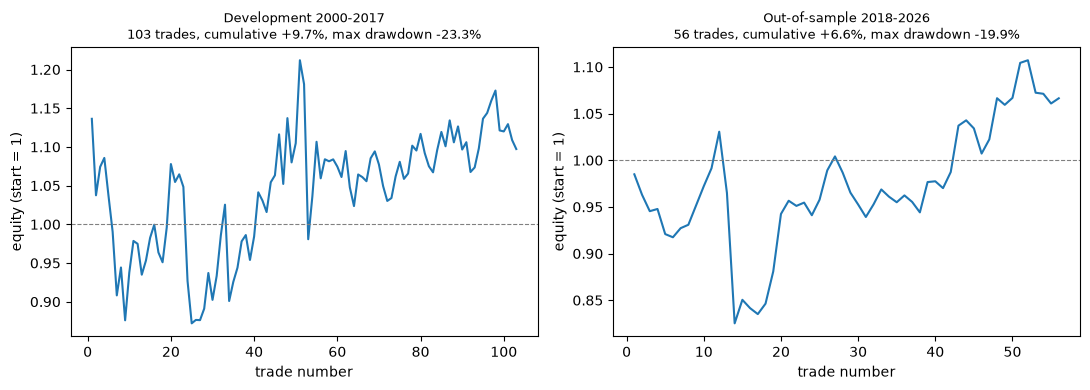

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, period, title in zip(axes, ["dev", "oos"], ["Development 2000-2017", "Out-of-sample 2018-2026"]):
    r = run_backtest(parts[period], cfg, mode="skip")
    ax.plot(range(1, len(r.equity) + 1), r.equity.values, lw=1.5)
    ax.axhline(1, color="grey", lw=0.8, ls="--")
    ax.set_title(f"{title}\n{r.n_trades} trades, cumulative {r.total_return:+.1%}, "
                 f"max drawdown {r.max_drawdown:.1%}", fontsize=9)
    ax.set_xlabel("trade number"); ax.set_ylabel("equity (start = 1)")
plt.tight_layout()
plt.savefig(ROOT / "docs" / "equity_curves.png", dpi=130)
plt.show()

**Backtest reading.** Mode A returns +17.01% over 159 trades across 26 years at the 0.10% cost
assumption, with a −25.3% maximum drawdown, while being invested only about 12% of days. At a 0.20%
cost assumption the same strategy returns −0.20%. Mode A and Mode B disagree in sign out-of-sample
(+6.64% vs −30.67%): the difference is only whether repeated events during the COVID crash are traded,
and those are the worst trades — so Mode A's positive result is flattered by the overlap rule rather
than by any risk control a trader could rely on.

## 10. Summary of the evidence

| | Development 2000–2017 | Out-of-sample 2018–2026 |
|---|---|---|
| Events (episodes) | 142 (96) | 72 (50) |
| Recovery rate, event vs baseline | 55.6% vs 40.5% → **+15.1pp**, p<0.001 | 58.3% vs 39.2% → **+19.1pp**, p=0.001 |
| 5-day return, event vs baseline | +0.556% vs +0.215% → +0.34pp, p=0.46 | −0.319% vs +0.122% → **−0.44pp**, p=0.61 |
| Win rate | 55.6% vs 56.3% | 50.0% vs 53.4% |
| Volatility | 4.82% vs 3.30% | 4.10% vs 2.14% |

**Supported by the evidence:** after a 2σ one-day fall, NIFTY regains at least half of that fall within
5 sessions materially more often than volatility-matched normal days, in development and out-of-sample,
in every regime cut, and under a stricter 100% definition. Post-event volatility rises to 1.5–1.9× the
baseline, which offers a mechanical explanation: larger swings make a partial retracement more likely
to be touched.

**Not supported:** that the bounce is capturable. The 5-day return advantage is indistinguishable from
zero in development, negative out-of-sample, negative after costs, and accompanied by a lower win rate
and roughly double the volatility.

**Against the pre-registered rejection criterion:** the tradable interpretation is rejected; the
recovery interpretation survives. The pattern is real as a description of price paths, and did not
convert into a return a trader could bank.